In [9]:
from typing import TypedDict, Optional

class AgentState(TypedDict):
    user_input: str
    selenium_code: Optional[str]
    result: Optional[str]

In [10]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

def natural_language_processing_node(state: AgentState) -> AgentState:
    user_input = state["user_input"]
    
    model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

    response = model.invoke([
        ("system", "너는 사용자의 자연어 명령을 Selenium 코드로 변환하는 AI이다. 파이썬 코드만 반환해라."),
        ("user", user_input)
    ])

    print("response>>>", response)
    
    # 응답 객체에서 content 속성을 통해 결과에 접근합니다.
    selenium_code = response.content
    
    state["selenium_code"] = selenium_code
    return state

In [11]:
def selenium_execution_node(state: AgentState) -> AgentState:
    selenium_code = state.get("selenium_code")
    if not selenium_code:
        state["result"] = "오류: 실행할 Selenium 코드가 없습니다."
        return state

    try:
        # 동적으로 Selenium 코드 실행
        # exec(selenium_code, globals(), {'driver': driver})
        state["result"] = "Selenium 명령이 성공적으로 실행되었습니다."
    except Exception as e:
        state["result"] = f"오류 발생: {e}"
    
    return state

In [12]:
from langgraph.graph import StateGraph, START

# 3. 그래프 생성
graph_builder = StateGraph(AgentState)
graph_builder.add_node("nlp_node", natural_language_processing_node)
graph_builder.add_node("execution_node", selenium_execution_node)

# START에서 nlp_node로 연결되는 엣지 추가
graph_builder.add_edge(START, "nlp_node")

# nlp_node에서 execution_node로 연결되는 엣지 추가
graph_builder.add_edge("nlp_node", "execution_node")

# 4. 그래프 컴파일
graph = graph_builder.compile()

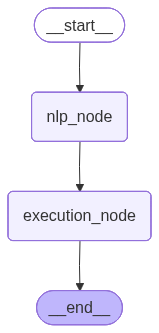

In [13]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [14]:
# 5. 프로그램 실행 루프는 그대로 유지합니다.
while True:
    user_input = input("명령을 입력하세요 (종료하려면 '종료' 입력): ")
    if user_input.lower() == '종료':
        break
    
    initial_state = {"user_input": user_input, "selenium_code": None, "result": None}
    final_state = graph.invoke(initial_state)
    
    print(f"결과: {final_state['result']}")

response>>> content='```python\nfrom selenium import webdriver\nfrom selenium.webdriver.chrome.service import Service\nfrom webdriver_manager.chrome import ChromeDriverManager\n\ndef open_naver():\n    try:\n        # Chrome WebDriver 설정 (최신 버전 자동 설치 및 서비스 시작)\n        service = Service(ChromeDriverManager().install())\n        driver = webdriver.Chrome(service=service)\n\n        # 네이버 열기\n        driver.get("https://www.naver.com")\n\n    except Exception as e:\n        print(f"오류 발생: {e}")\n\nif __name__ == "__main__":\n    open_naver()\n```' additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []} id='run--6f7a22f2-0964-436c-83eb-cd7f07d9cb81-0' usage_metadata={'input_tokens': 36, 'output_tokens': 138, 'total_tokens': 174, 'input_token_details': {'cache_read': 0}}
결과: Selenium 명령이 성공적으로 실행되었습니다.
